# Strassen algorithm for matrix products

## 背景

Strassen algorithmは$N\times N$行列の行列積計算を効率的に行う方法である。(初等教育の筆算を素朴に行うと) $N$桁の数同士の和は$\mathcal{O}(N)$, 積は$\mathcal{O}(N^2)$になることが知られている。乗算はKaratsuba法 $\mathcal{O}(N^{\log_23})$　(https://ja.wikipedia.org/wiki/カラツバ法) やFFTの利用$\mathcal{O}(N\log N\log \log N)$によりアルゴリズムを効率化しても$\mathcal{O}(N)$には届いていないようである。

したがって行列積の計算量は発生する乗算の回数に依存する。定義通りに
$$
A_{ij}
=
\sum_{k=0}^{N-1}B_{ik}C_{kj}
$$
を計算すると、1成分計算するのに$N$回、$N^2$成分回して$\mathcal{O}(N^3)$が必要である。小行列に分割しても、
$$
\left(\begin{matrix}
    B_{00}C_{00} + B_{01}C_{10}
    &
    B_{00}C_{01} + B_{01}C_{11}
    \\
    B_{10}C_{00} + B_{11}C_{10}
    &
    B_{10}C_{01} + B_{11}C_{11}
\end{matrix}\right)
$$
を眺めると、乗算はやはり8回発生する。$N$を2進数で書いて再起的に計算しても$\mathcal{O}(N^3)$が必要。

なお入出力のデータすべてにアクセスしなければならないので、原理的に$\mathcal{O}(N^2)$を下回ることは決してない。

## Strassen algorithm

小行列の計算において以下7つの行列を作る。
$$
\begin{split}
    P_1
    &=
    (A_{00}+A_{11})
    (B_{00}+B_{11})
    \\
    P_2
    &=
    (A_{10}+A_{11})
    B_{00}
    \\
    P_3
    &=
    A_{00}
    (B_{01}-B_{11})
    \\
    P_4
    &=
    A_{11}
    (B_{10}-B_{00})
    \\
    P_5
    &=
    (A_{00}+A_{01})
    B_{11}
    \\
    P_6
    &=
    (A_{10}-A_{00})
    (B_{00}+B_{01})
    \\
    P_7
    &=
    (A_{01}-A_{11})
    (B_{10}+B_{11})
\end{split}
$$
結果は
$$
\begin{split}
    C_{00}
    &=
    P_1+P_4-P_5+P_7
    \\
    C_{01}
    &=
    P_3+P_5
    \\
    C_{10}
    &=
    P_2+P_4
    \\
    C_{11}
    &=
    P_1+P_3-P_2+P_6
\end{split}
$$
となる。
再起的に行うことで、定義通りの計算では8回必要だった乗算が7回に抑えられている。

計算量を評価する。$N\times N$行列を$N/2\times N/2$小行列4つへの分割と解釈し、7回計算で行列積が計算される。即ち$7\times (N/2\times N/2\text{行列積})$. 再起的に$\log_2 N$回繰り返し、
$$
7^{\log_2 N}
=
2^{\log_2 N\times\log_2 7}
=
N^{\log_2 7}
\approx
N^{2.8}
$$
となる。

## 実装

In [42]:
using LinearAlgebra
using BenchmarkTools
using Plots

$N=2^L$にして実装する。まずは初等的な計算。

In [43]:
function MatrixProductDirect(size, A, B)
    C = zeros(eltype(A), size, size)
    @inbounds for i in 1:size
        for j in 1:size
            s = zero(eltype(A))
            for k in 1:size
                s += A[i, k] * B[k, j]
            end
            C[i, j] = s
        end
    end
    return C
end

MatrixProductDirect (generic function with 1 method)

Strassenのアルゴリズムを実装する。再起計算を最後まで繰り返すとアロケーションのコストの方が大きくなるため、ちょうど良い頃合い ($N=64$) になったら初等的な行列積計算に移る。

In [44]:
function MatrixProductStrassen(size, A, B; cutoff=64)
    if size <= cutoff
        return MatrixProductDirect(size, A, B)
    elseif isodd(size)
        error("size must be a power of 2")
    end

    half = size ÷ 2

    A11 = @view A[1:half, 1:half]
    A12 = @view A[1:half, half+1:size]
    A21 = @view A[half+1:size, 1:half]
    A22 = @view A[half+1:size, half+1:size]
    B11 = @view B[1:half, 1:half]
    B12 = @view B[1:half, half+1:size]
    B21 = @view B[half+1:size, 1:half]
    B22 = @view B[half+1:size, half+1:size]

    P1 = MatrixProductStrassen(half, A11 .+ A22, B11 .+ B22; cutoff=cutoff)
    P2 = MatrixProductStrassen(half, A21 .+ A22, B11; cutoff=cutoff)
    P3 = MatrixProductStrassen(half, A11, B12 .- B22; cutoff=cutoff)
    P4 = MatrixProductStrassen(half, A22, B21 .- B11; cutoff=cutoff)
    P5 = MatrixProductStrassen(half, A11 .+ A12, B22; cutoff=cutoff)
    P6 = MatrixProductStrassen(half, A21 .- A11, B11 .+ B12; cutoff=cutoff)
    P7 = MatrixProductStrassen(half, A12 .- A22, B21 .+ B22; cutoff=cutoff)

    C = Matrix{eltype(A)}(undef, size, size)
    @views begin
        C[1:half, 1:half] .= P1 .+ P4 .- P5 .+ P7
        C[1:half, half+1:size] .= P3 .+ P5
        C[half+1:size, 1:half] .= P2 .+ P4
        C[half+1:size, half+1:size] .= P1 .- P2 .+ P3 .+ P6
    end

    return C
end

MatrixProductStrassen (generic function with 1 method)

何度か実行を繰り返して実行時間を測定する。

In [45]:
function benchmark_mean(f; samples=10)
    t = @benchmark $f() samples=samples evals=1
    return median(t).time * 1e-9  # ns -> s
end

cutoff = 64
Lrange = 3:10
runtime = zeros(length(Lrange), 2)
ratio = zeros(length(Lrange))

for (idx, L) in enumerate(Lrange)
    N = 2^L
    A = rand(N, N)
    B = rand(N, N)

    runtime[idx, 1] = benchmark_mean(() -> MatrixProductStrassen(N, A, B; cutoff=cutoff); samples=2)
    runtime[idx, 2] = benchmark_mean(() -> MatrixProductDirect(N, A, B); samples=2)
    ratio[idx] = runtime[idx, 1] / runtime[idx, 2]

    println("N=$N, Strassen=$(runtime[idx, 1]) s, Elementary=$(runtime[idx, 2]) s, ratio=$(ratio[idx])")
end

N=8, Strassen=3.9165000000000005e-6 s, Elementary=1.0835e-6 s, ratio=3.614674665436087
N=16, Strassen=5.333500000000001e-6 s, Elementary=2.6875e-6 s, ratio=1.984558139534884
N=32, Strassen=1.2313e-5 s, Elementary=1.25415e-5 s, ratio=0.9817804887772595
N=64, Strassen=7.55835e-5 s, Elementary=7.41045e-5 s, ratio=1.0199583021274012
N=128, Strassen=0.000562771 s, Elementary=0.0008333335000000001 s, ratio=0.6753250649349869
N=256, Strassen=0.00437475 s, Elementary=0.0098711245 s, ratio=0.443186589329311
N=512, Strassen=0.035594437 s, Elementary=0.10955000000000001 s, ratio=0.32491498858968504
N=1024, Strassen=0.410472771 s, Elementary=0.9251565625000001 s, ratio=0.443679251315909


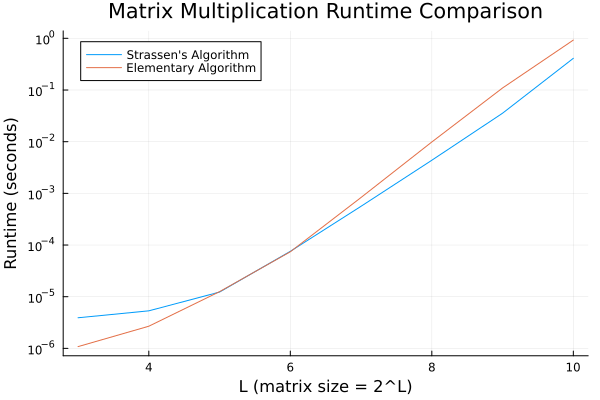

In [47]:
using Plots
plot(Lrange, runtime[:, 1], label="Strassen's Algorithm", xlabel="L (matrix size = 2^L)", ylabel="Runtime (seconds)", title="Matrix Multiplication Runtime Comparison", yscale=:log10, legend=:topleft)
plot!(Lrange, runtime[:, 2], label="Elementary Algorithm", yscale=:log10)
# savefig("strasse.png")

サイズの大きな行列積にてStrassen's algorithmの優位性がわかる。

## 進展

最近の研究の進展によりさらに高速になっている。$\mathcal{O}(N^\omega)$ の $\omega$ は 近年さらに改善されている。Gemini Deep Researchの結果から特に重要そうなものを抜き出すだけでも以下のようになる。

| 発表年 | ω の上限値 | 著者・研究チーム | 主要な導入技術・特記事項 | 出典 |
| - | - | - | - | - |
| - | $3.0000$ | (Naive Algorithm) | 標準的な定義による計算手法 | |
| 1969 | $2.8074$ | V. Strassen | 分割統治法による再帰的アルゴリズム | [V. Strassen, "Gaussian elimination is not optimal." Numer. Math. **13**, 354–356 (1969).](https://doi.org/10.1007/BF02165411) |
| 1978 | $2.7960$ | V. Pan | 三線形集約（Trilinear aggregation） | [V. Y. Pan, "Strassen's algorithm is not optimal trilinear technique of aggregating, uniting and canceling for constructing fast algorithms for matrix operations," SCFS 1978, Ann Arbor, 166-176, 1978.](https://doi.org/10.1109/SFCS.1978.34)
| 1979 | $2.7799$ | D. Bini et al. | 境界ランク（Border rank）の導入 | [Dario Bini, Milvio Capovani, Francesco Romani, Grazia Lotti, "$O(n^{2.7799})$ complexity for $n \times n$ approximate matrix multiplication", Information Processing Letters, **8**, 234 (1979).](https://doi.org/10.1016/0020-0190(79)90113-3) |
| 1981 | $2.5220$ | A. Schönhage | 漸近的和の不等式（$\tau$-theorem）| [A. Schönhage, "Partial and Total Matrix Multiplication", HomeSIAM Journal on ComputingVol. **10**, 434 (1981)](https://doi.org/10.1137/0210032) |
| 1986 | $2.4790$ | V. Strassen | レーザー法（Laser method）の導入 | [V. Strassen, "Relative bilinear complexity and matrix multiplication." Journal für die reine und angewandte Mathematik, **1987**, 406 (1987).](https://doi.org/10.1515/crll.1987.375-376.406) |
| 2010 | $2.3737$ | A. Stothers | $CW_q$ の高次累乗解析の開始 | [A. Stothers, "On the Complexity of Matrix Multiplication", University of Edinburgh.](https://era.ed.ac.uk/server/api/core/bitstreams/34a79da9-2d27-47a8-a483-217f48515169/content) | 
| 2023 | $2.371866$ | Duan, Wu, Zhou | 「隠れた損失（Hidden loss）」の発見と修正 | [R. Duan, H. Wu, R. Zhou "Faster Matrix Multiplication via Asymmetric Hashing", 2023 IEEE 64th Annual Symposium on Foundations of Computer Science (FOCS), 2129 (2023).](https://doi.ieeecomputersociety.org/10.1109/FOCS57990.2023.00130)
| 2024 | $2.371339$ | Alman, Duan, Williams, et al. | 解析の完全な非対称性（Asymmetry）の導入  | [J. Alman, R. Duan, V. Williams, Y. Xu, Z. Xu, R. Zhou, "More Asymmetry Yields Faster Matrix Multiplication", Proceedings of the 2025 Annual ACM-SIAM Symposium on Discrete Algorithms (SODA) (2025)](https://doi.org/10.1137/1.9781611978322.63) |